In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier


data = pd.read_csv("dataset2.csv")
print(data.columns.tolist())

['video_id', 'trending_date', 'title', 'channel_title', 'category_id', 'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count', 'thumbnail_link', 'comments_disabled', 'ratings_disabled', 'video_error_or_removed', 'description']


In [ ]:
print(data.shape)
print(data.columns)
print(data.info())
print(data.describe())

(6351, 16)
Index(['video_id', 'trending_date', 'title', 'channel_title', 'category_id',
       'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count',
       'thumbnail_link', 'comments_disabled', 'ratings_disabled',
       'video_error_or_removed', 'description'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6351 entries, 0 to 6350
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                6351 non-null   object
 1   trending_date           6351 non-null   object
 2   title                   6351 non-null   object
 3   channel_title           6351 non-null   object
 4   category_id             6351 non-null   int64 
 5   publish_time            6351 non-null   object
 6   tags                    6351 non-null   object
 7   views                   6351 non-null   int64 
 8   likes                   6351 non-null   int64 
 9   dislikes     

In [4]:
print("\nMissing Values")
print(data.isnull().sum())


Missing Values
video_id                   0
trending_date              0
title                      0
channel_title              0
category_id                0
publish_time               0
tags                       0
views                      0
likes                      0
dislikes                   0
comment_count              0
thumbnail_link             0
comments_disabled          0
ratings_disabled           0
video_error_or_removed     0
description               98
dtype: int64


# Feature Engineering

In [5]:
data["description"] = data["description"].fillna("")
data["description_length"] = data["description"].str.len()
data["description"] = data["description"].fillna("")

# loging

In [6]:
data['publish_time'] = pd.to_datetime(data['publish_time']) 
data['publish_weekday'] = data['publish_time'].dt.dayofweek 
data['publish_month'] = data['publish_time'].dt.month
data['like_comment_ratio'] = data['likes'] / (data['comment_count'] + 1) 
data['total_engagement'] = data['likes'] + data['dislikes'] + data['comment_count']

threshold = data['views'].quantile(0.75) 
data['trend_fast'] = (data['views'] > threshold).astype(int) 
print(data[['views', 'trend_fast']].head())

       views  trend_fast
0  225211923           1
1  149376127           1
2  148689896           1
3  139334502           1
4  123010920           1


# EDA

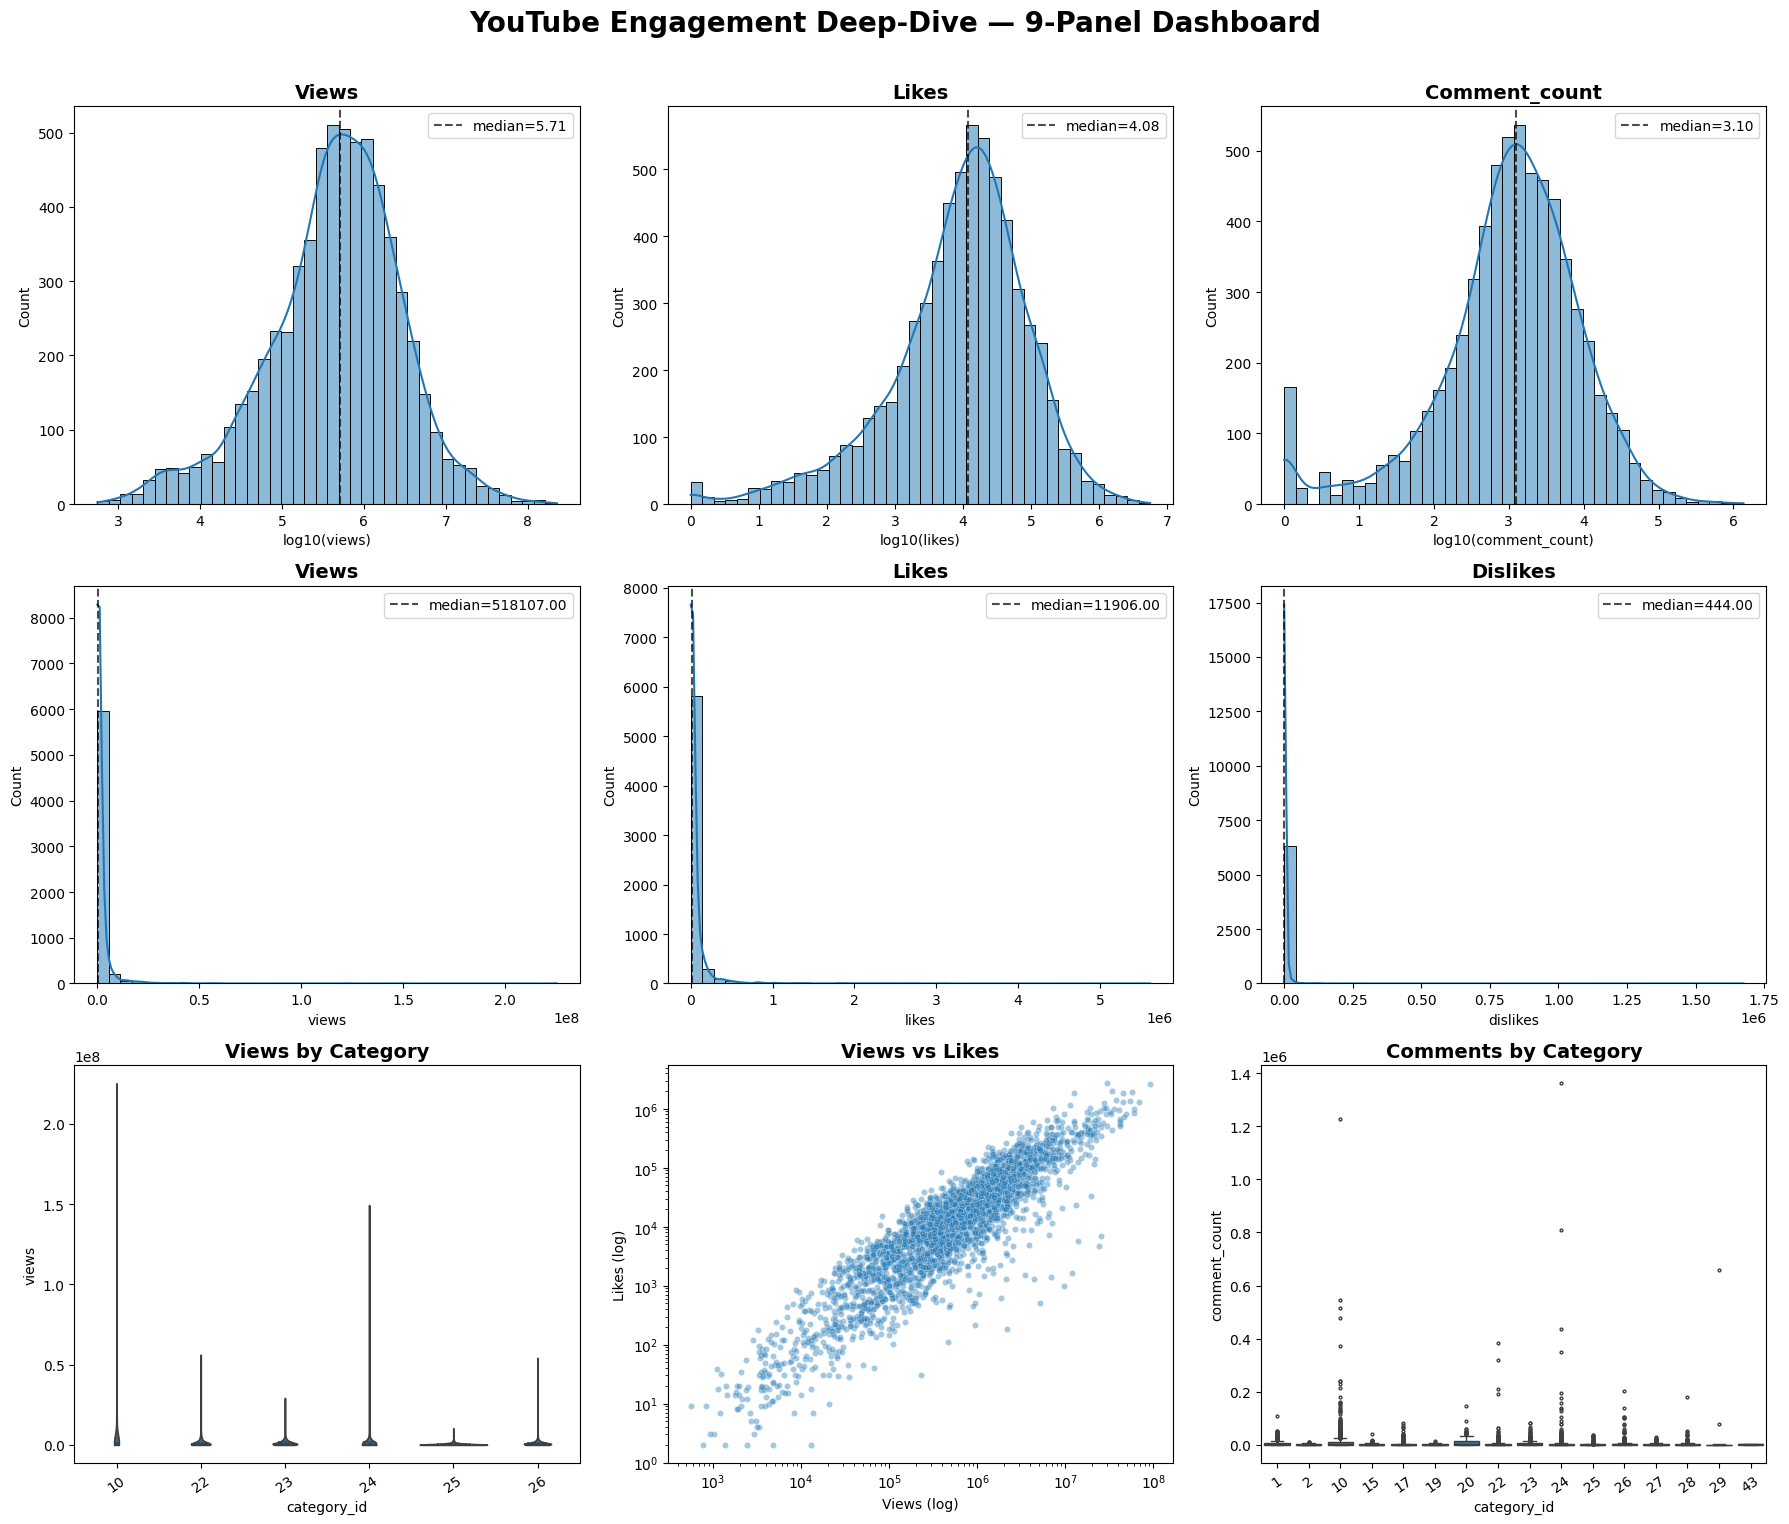

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(18, 16))
fig.suptitle("YouTube Engagement Deep-Dive — 9-Panel Dashboard", fontsize=20, fontweight='bold', y=0.98)

for i, col in enumerate(["views", "likes", "comment_count"]):
    log_data = np.log10(data[col].clip(lower=1))
    sns.histplot(log_data, bins=40, kde=True, ax=axes[0, i])
    median_val = log_data.median()
    axes[0, i].axvline(median_val, color='black', linestyle='--', alpha=0.7, 
                       label=f"median={median_val:.2f}")
    axes[0, i].set_title(col.capitalize(), fontsize=14, fontweight='bold')
    axes[0, i].set_xlabel(f"log10({col})")
    axes[0, i].legend()

for i, col in enumerate(["views", "likes", "dislikes"]):
    sns.histplot(data[col], bins=40, kde=True, ax=axes[1, i])
    median_val = data[col].median()
    axes[1, i].axvline(median_val, color='black', linestyle='--', alpha=0.7, 
                       label=f"median={median_val:.2f}")
    axes[1, i].set_title(col.replace("_", " ").title(), fontsize=14, fontweight='bold')
    axes[1, i].set_xlabel(col)
    axes[1, i].legend()

top_cats = data["category_id"].value_counts().head(6).index
sns.violinplot(data=data[data["category_id"].isin(top_cats)], x="category_id", y="views", 
               ax=axes[2, 0], inner="quartile", cut=0)
axes[2, 0].set_title("Views by Category", fontsize=14, fontweight='bold')
axes[2, 0].tick_params(axis='x', rotation=35)

sample_df = data.sample(min(len(data), 3000), random_state=42)
sns.scatterplot(data=sample_df, x="views", y="likes", ax=axes[2, 1], alpha=0.4, s=20)
axes[2, 1].set_xscale("log")
axes[2, 1].set_yscale("log")
axes[2, 1].set_title("Views vs Likes", fontsize=14, fontweight='bold')
axes[2, 1].set_xlabel("Views (log)")
axes[2, 1].set_ylabel("Likes (log)")

sns.boxplot(data=data, x="category_id", y="comment_count", ax=axes[2, 2], fliersize=2)
axes[2, 2].set_title("Comments by Category", fontsize=14, fontweight='bold')
axes[2, 2].tick_params(axis='x', rotation=35)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

/var/folders/xz/jl0x7g45257404n2n3_cp3xh0000gn/T/ipykernel_3407/1895960676.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


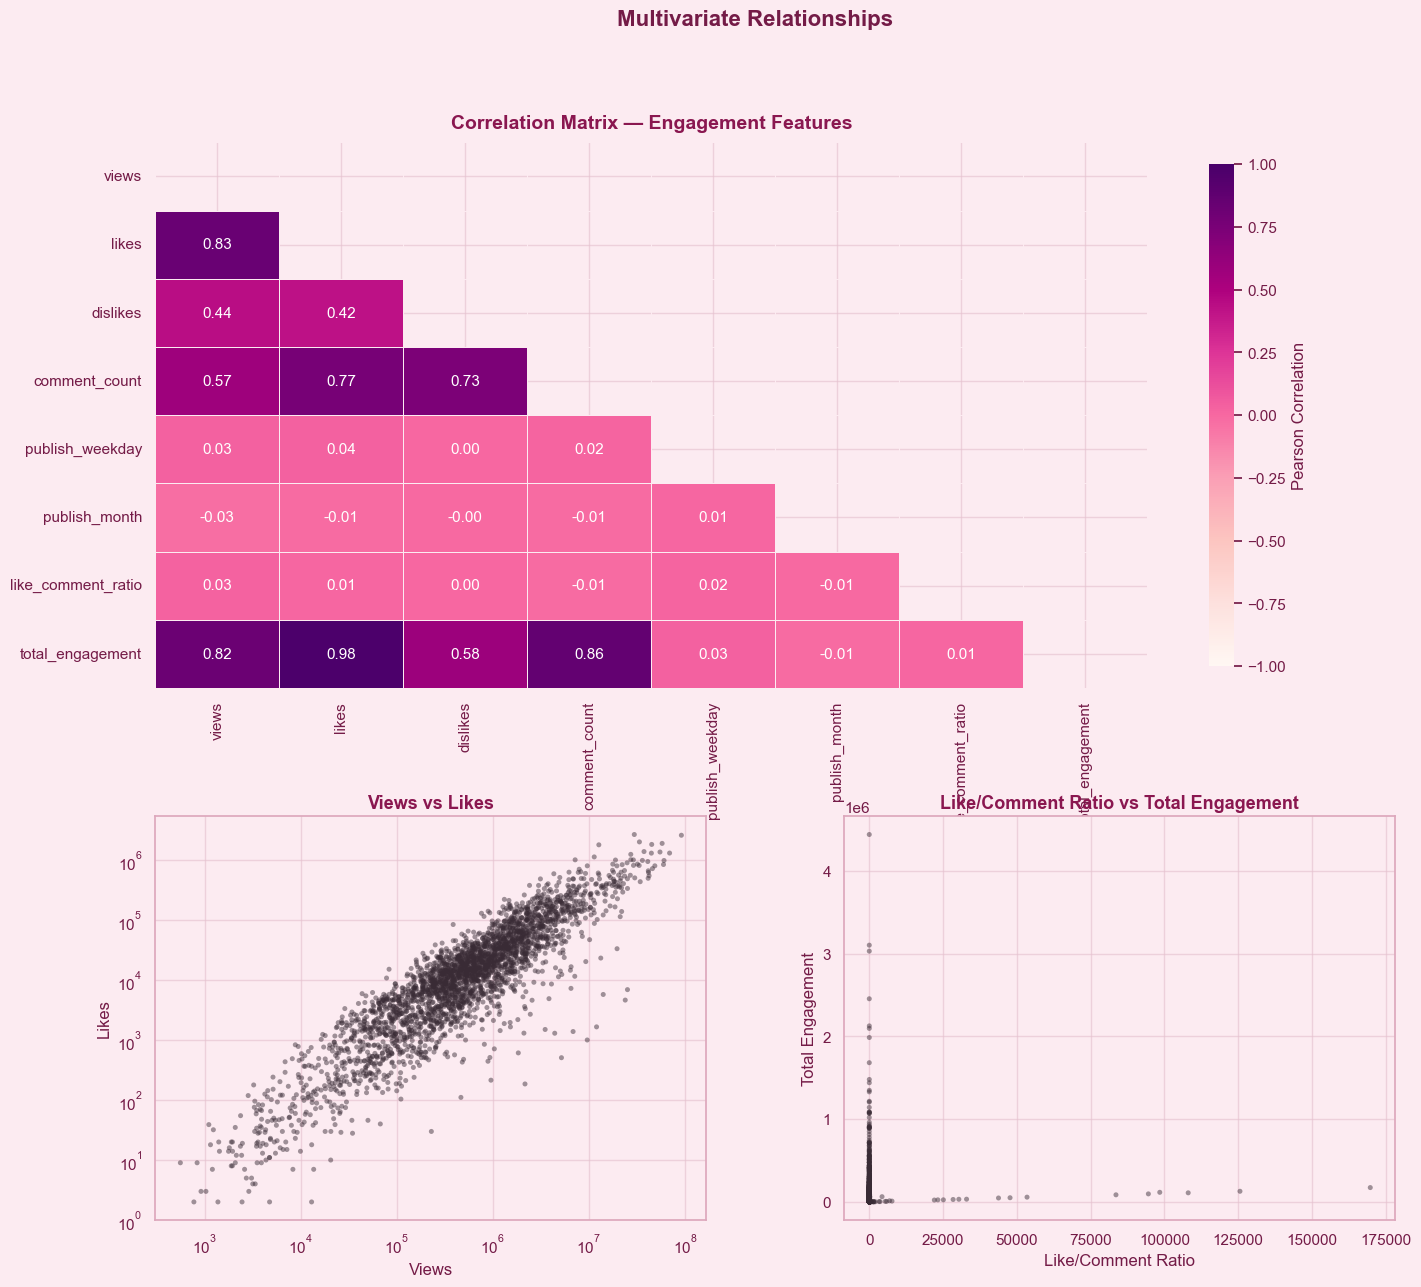

In [8]:
corr_cols = [
    "views", "likes", "dislikes", "comment_count",
    "publish_weekday", "publish_month",
    "like_comment_ratio", "total_engagement"
]

available_cols = [col for col in corr_cols if col in data.columns]
corr_data = data[available_cols].replace([np.inf, -np.inf], np.nan).dropna()
corr = corr_data.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.facecolor": "#FCEBF1",
    "axes.facecolor": "#FCEBF1",
    "axes.edgecolor": "#DDA8BC",
    "axes.labelcolor": "#741B47",
    "axes.titlecolor": "#8A1750",
    "xtick.color": "#741B47",
    "ytick.color": "#741B47",
    "text.color": "#741B47",
    "grid.color": "#E6C2D0",
    "grid.alpha": 0.65,
    "font.size": 11
})

fig = plt.figure(figsize=(16, 14), facecolor="#FCEBF1")
gs = fig.add_gridspec(2, 2, height_ratios=[1.35, 1], hspace=0.27, wspace=0.25)

ax_h = fig.add_subplot(gs[0, :])
ax_l = fig.add_subplot(gs[1, 0])
ax_r = fig.add_subplot(gs[1, 1])

sns.heatmap(
    corr,
    mask=mask,
    cmap="RdPu",
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.7,
    linecolor="#FCEBF1",
    square=False,
    cbar=True,
    cbar_kws={"label": "Pearson Correlation", "shrink": 0.92, "pad": 0.05},
    ax=ax_h
)
ax_h.set_title("Correlation Matrix — Engagement Features", fontsize=14, fontweight="bold", pad=10)

sample = corr_data.sample(min(3000, len(corr_data)), random_state=42)

ax_l.scatter(sample["views"], sample["likes"], color="#392B35", s=13, alpha=0.48, edgecolors="none")
ax_l.set_xscale("log")
ax_l.set_yscale("log")
ax_l.set_title("Views vs Likes", fontsize=13, fontweight="bold")
ax_l.set_xlabel("Views")
ax_l.set_ylabel("Likes")

ax_r.scatter(sample["like_comment_ratio"], sample["total_engagement"], color="#392B35", s=13, alpha=0.48, edgecolors="none")
ax_r.set_title("Like/Comment Ratio vs Total Engagement", fontsize=13, fontweight="bold")
ax_r.set_xlabel("Like/Comment Ratio")
ax_r.set_ylabel("Total Engagement")

for ax in [ax_h, ax_l, ax_r]:
    for spine in ax.spines.values():
        spine.set_color("#DDA8BC")

fig.suptitle("Multivariate Relationships", fontsize=16, fontweight="bold", color="#741B47", y=0.975)
plt.tight_layout()
plt.savefig("multivariate_relationships_pink.png", dpi=300, bbox_inches="tight", facecolor="#FCEBF1")
plt.show()

In [9]:
drop_cols = ['video_id', 'title', 'channel_title', 'publish_time', 
             'trending_date', 'thumbnail_link', 'description', 'tags']
data = data.drop(columns=drop_cols, errors='ignore')

data = data.replace([np.inf, -np.inf], np.nan).dropna()


# Feature Selection

In [10]:
features = [ 'likes', 'dislikes', 'comment_count', 'publish_weekday', 'publish_month', 'like_comment_ratio', 'total_engagement' ]

x = data[features] 
y = data['trend_fast']

# Train-Test Split


In [ ]:
scaler = StandardScaler() 
x_scaled = scaler.fit_transform(x)
x_train, x_test, y_train, y_test = train_test_split( x_scaled, y, test_size=0.2, random_state=42 )

# Model Initialization

In [ ]:
model = XGBClassifier( n_estimators=200,
    learning_rate=0.03, 
    max_depth=3,
    min_child_weight=5, 
    subsample=0.7, 
    colsample_bytree=0.7, 
    reg_alpha=1.0, 
    reg_lambda=2.0, 
    random_state=42, 
    eval_metric='logloss' 
)

model.fit(x_train, y_train)
model.score(x_test , y_test)

0.9103068450039339

In [12]:
model.fit(x_train, y_train)

train_acc = model.score(x_train, y_train)
test_acc = model.score(x_test, y_test)

print(f"Train: {train_acc*100:.2f}%")
print(f"Test: {test_acc*100:.2f}%")
print(f"Diff: {(train_acc - test_acc)*100:.2f}%")

Train: 91.97%
Test: 91.03%
Diff: 0.94%
